g:\VScode\CTAD2\CTAD2\stage2_1\chip_temp_pred_models.py:122: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  inchip_pred_model.load_state_dict(torch.load(inchip_model_weight_f

Using device: cpu
Initializing Layout...
Layout initialized. Calculating initial cost...
Initial Cost calculated: 159.0689697265625


SA Optimization: 167it [06:43,  2.41s/it, Best=26.52, T=0.1]                          



Optimization Finished!
Final Best Fitness: 26.517505645751953


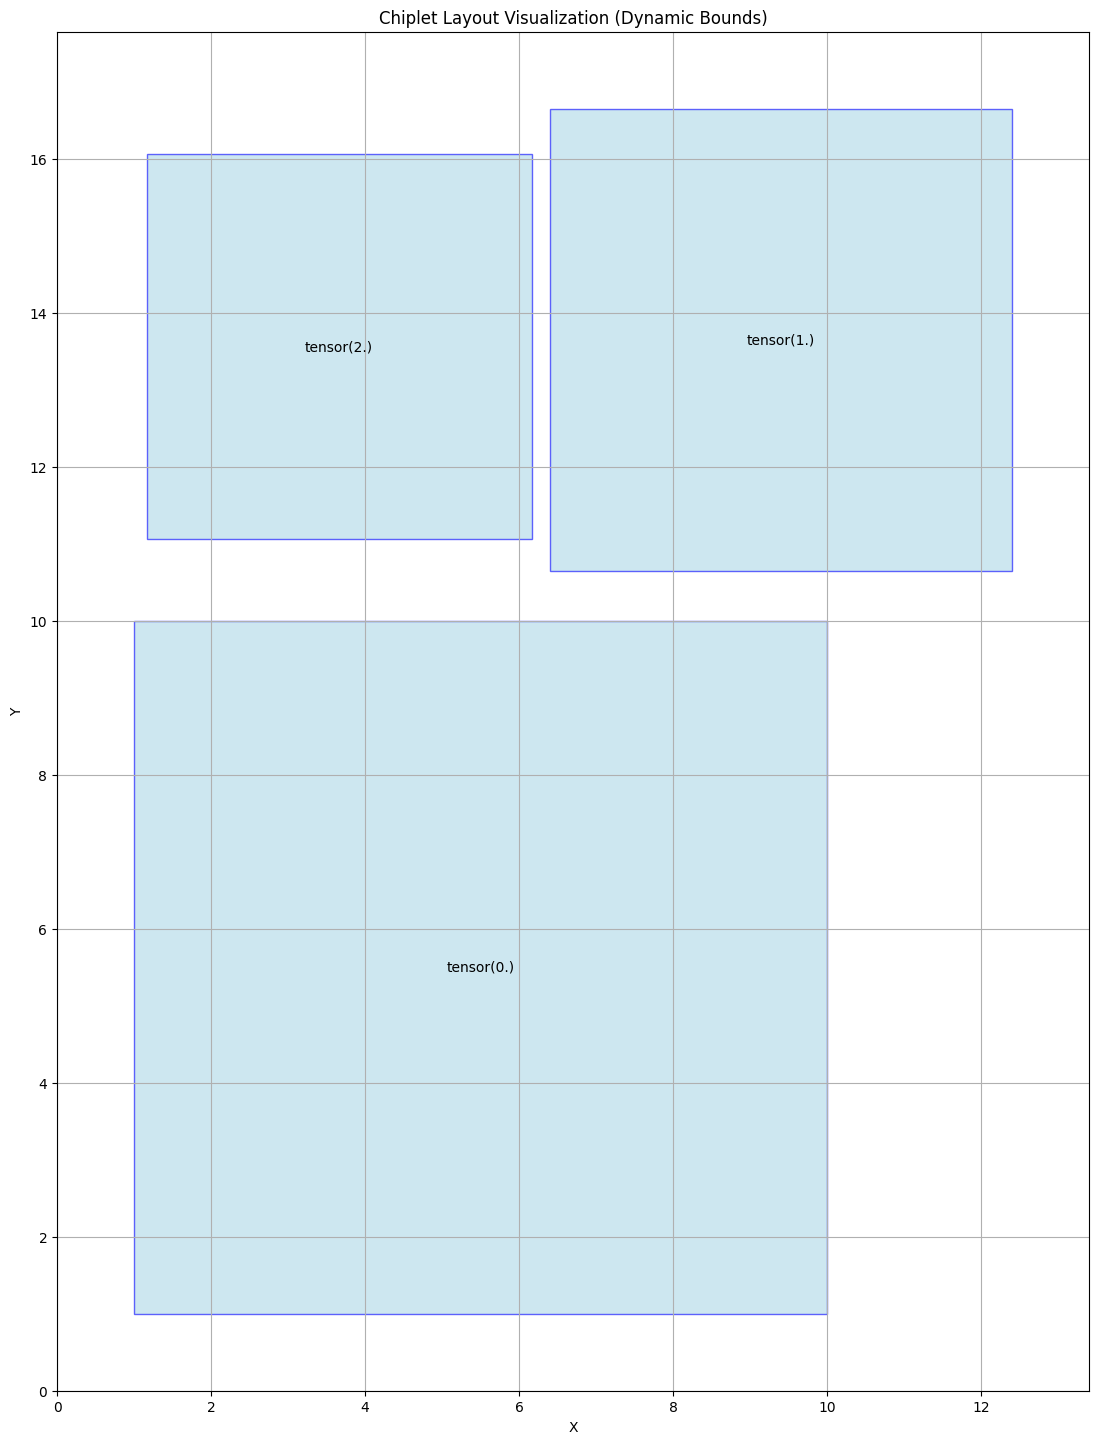

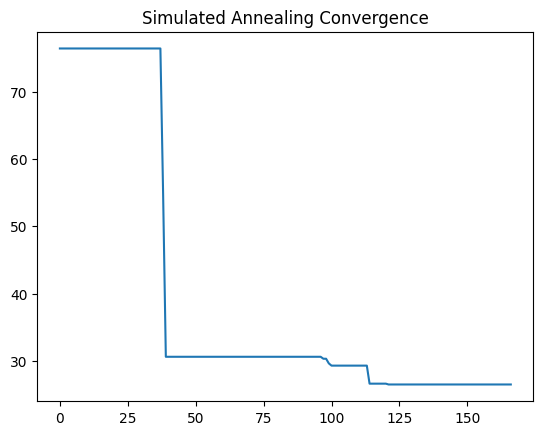

In [1]:
import torch
import numpy as np
import random
import math
from tqdm import tqdm
import matplotlib.pyplot as plt

# 导入已有的模块文件
import utilities
import interconnect_calculator as inter_cal
import temperature_calculator as temp_cal
import chip_temp_pred_models as ctpm

import warnings
# 强力屏蔽警告
warnings.filterwarnings("ignore")

# ================= 配置与常量 =================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

# ================= 1. 移植自 stage2_1_cuda.ipynb 的核心辅助函数 =================
# 这些函数原先在 notebook 中，现在直接定义在这里以避免 Import Error

def get_chiplet_dict_cuda(chip_length, chip_width, Convection_Film_Coefficient, Internal_Heat_Generation_Magnitude): 
    """
    创建 Chiplet 属性字典，并调用代理模型获取热衰减系数 A, k         dictionary
    """
    chip = dict()
    chip['len'] = chip_length
    chip['wid'] = chip_width
    chip['CFC'] = Convection_Film_Coefficient
    chip['IHGM'] = Internal_Heat_Generation_Magnitude

    # 调用热代理模型计算 A 和 k
    chip['A'], chip['k'] = ctpm.get_out_chip_decay_curve_coef(
        chip_len=chip['len'],
        chip_wid=chip['wid'],
        Convection_Film_Coefficient=chip['CFC'],
        Internal_Heat_Generation_Magnitude=chip['IHGM']
    )
    return chip

def is_2_chip_overlapping_cuda(chip1, chip2, min_edge_dist:float=0.2): 
    """
    判断两个 Chiplet 是否重叠 (辅助函数)
    """
    x1, y1, w1, h1 = chip1[0].item(), chip1[1].item(), chip1[2].item(), chip1[3].item()
    x2, y2, w2, h2 = chip2[0].item(), chip2[1].item(), chip2[2].item(), chip2[3].item()

    no_overlap = (x1 + w1 + min_edge_dist <= x2 or \
                  x2 + w2 + min_edge_dist <= x1) or \
                 (y1 + h1 + min_edge_dist <= y2 or \
                  y2 + h2 + min_edge_dist <= y1)
      
    return not no_overlap

def is_overlapping_in_init_grid_cuda(x_c, y_c, len_c, wid_c, index_c, layout, min_edge_dist): 
    """
    判断当前 Chiplet 是否与 layout 中已有的 Chiplet 重叠
    """
    # 同样强制转换为 float32
    curr_chip = torch.tensor([x_c, y_c, len_c, wid_c, index_c], device=DEVICE, dtype=torch.float32)
    n = len(layout)
    if n == 0: return False
    
    for i in range(n):
        if is_2_chip_overlapping_cuda(curr_chip, layout[i], min_edge_dist):
            return True
    return False

def generate_a_layout_cuda(grid_length, grid_width, chiplets: dict, min_edge_distance: float=2.0, margin_width: float=1.0): 
    """
    随机生成一个合法的初始布局 (修正版：强制使用 float32)
    """
    # 初始化为空张量
    layout = torch.tensor([], device=DEVICE)

    for index, chip in chiplets.items(): 
        placed = False
        while not placed: 
            # 随机采样位置
            x = random.randint(0, int(grid_length - chip['len']))
            y = random.randint(0, int(grid_width - chip['wid']))
            
            # 检查重叠
            if len(layout) == 0 or not is_overlapping_in_init_grid_cuda(x, y, chip['len'], chip['wid'], index, layout, min_edge_dist=min_edge_distance): 
                # ==================== 修改点 ====================
                # 这里添加 dtype=torch.float32，确保生成的张量是浮点型
                chip_tensor = torch.tensor([x, y, chip['len'], chip['wid'], index], device=DEVICE, dtype=torch.float32)
                # ===============================================
                
                if len(layout) == 0:
                    layout = chip_tensor.unsqueeze(0)
                else:
                    layout = torch.cat((layout, chip_tensor.unsqueeze(0)), dim=0)
                placed = True

    # 裁剪画布
    if len(layout) > 0:
        x_min = torch.min(layout[:, 0])
        y_min = torch.min(layout[:, 1])
        # 现在 layout 是 float32，这里减去 float 类型不会报错
        layout[:, 0] -= (x_min - margin_width)
        layout[:, 1] -= (y_min - margin_width)
        
    return layout

def check_overlap_within_layout_cuda(layout):
    """
    检查整个布局内部是否有任意重叠 (用于SA扰动后的检查)
    """
    if not torch.is_tensor(layout):
        layout = torch.tensor(layout, device=DEVICE)
    
    n = len(layout)
    if n <= 1: return False
    
    i_indices, j_indices = torch.triu_indices(n, n, offset=1)
    
    x = layout[:, 0]
    y = layout[:, 1]
    w = layout[:, 2]
    h = layout[:, 3]
    
    min_dist = 0.2
    
    xi, yi, wi, hi = x[i_indices], y[i_indices], w[i_indices], h[i_indices]
    xj, yj, wj, hj = x[j_indices], y[j_indices], w[j_indices], h[j_indices]
    
    no_overlap = (xi + wi + min_dist <= xj) | \
                 (xj + wj + min_dist <= xi) | \
                 (yi + hi + min_dist <= yj) | \
                 (yj + hj + min_dist <= yi)
                 
    return (~no_overlap).any().item()

# ================= 2. 模拟退火 (SA) 核心逻辑 =================

def fitness_sa(layout, connectivity, chiplets):
    """
    SA 适应度函数：越小越好
    """
    if not torch.is_tensor(layout):
        layout = torch.tensor(layout, device=DEVICE, dtype=torch.float32)
        
    # 1. 互连线长度
    inter_connect_length = inter_cal.get_total_interconnect_length_cuda(
        layout=layout, 
        connectivity_pairs=connectivity
    )

    # 2. 热分布 (Max Temp + Uniformity)
    max_temp, temp_uniformity = temp_cal.get_max_temp_and_temp_uniformity_cuda(
        layout, chiplets
    )
    
    # 3. 扩散惩罚 (避免 Chiplet 跑得太远)
    coords = torch.stack([
        layout[:, 0] + layout[:, 2]*0.5,
        layout[:, 1] + layout[:, 3]*0.5
    ], dim=1)
    centroid = coords.mean(dim=0)
    diff = coords - centroid
    dist_sq = diff[:, 0]**2 + diff[:, 1]**2
    spread_penalty = dist_sq.sum() * 0.2 
    
    total_cost = inter_connect_length + temp_uniformity + spread_penalty
    return total_cost.item()

def generate_neighbor(current_layout, chiplets, grid_len, step_scale=1.0):
    """
    生成邻域解
    """
    new_layout = current_layout.clone()
    num_chips = len(new_layout)
    max_attempts = 50
    
    for _ in range(max_attempts):
        idx = random.randint(0, num_chips - 1)
        action = random.random()
        old_chip = new_layout[idx].clone()
        
        if action < 0.7: 
            # 平移
            move_range = grid_len * 0.2 * step_scale 
            dx = random.uniform(-move_range, move_range)
            dy = random.uniform(-move_range, move_range)
            new_layout[idx][0] += dx
            new_layout[idx][1] += dy
        elif action < 0.85:
            # 交换位置
            swap_idx = random.randint(0, num_chips - 1)
            if swap_idx != idx:
                temp_x, temp_y = new_layout[idx][0].item(), new_layout[idx][1].item()
                new_layout[idx][0] = new_layout[swap_idx][0]
                new_layout[idx][1] = new_layout[swap_idx][1]
                new_layout[swap_idx][0] = temp_x
                new_layout[swap_idx][1] = temp_y
        else:
            # 旋转
            temp_len = new_layout[idx][2].item()
            new_layout[idx][2] = new_layout[idx][3]
            new_layout[idx][3] = temp_len

        # 约束检查：不重叠则返回，重叠则回滚重试
        if not check_overlap_within_layout_cuda(new_layout):
            # 归一化坐标防止越界
            x_min = torch.min(new_layout[:, 0])
            y_min = torch.min(new_layout[:, 1])
            new_layout[:, 0] -= (x_min - 1.0)
            new_layout[:, 1] -= (y_min - 1.0)
            return new_layout
        else:
            # 回滚
            if action < 0.85 and action >= 0.7: # Swap 失败比较麻烦，直接重置整个 layout
                 new_layout = current_layout.clone()
            else:
                 new_layout[idx] = old_chip

    return None

def simulated_annealing(chiplets, connectivity, initial_temp=1000, final_temp=1, alpha=0.98, max_iter_per_temp=50):
    print("Initializing Layout...")
    avg_dim = utilities.avg([c['len'] for c in chiplets.values()])
    grid_len = (avg_dim + 5) * len(chiplets)
    grid_wid = grid_len
    
    # 1. 生成初始布局
    current_layout = generate_a_layout_cuda(grid_len, grid_wid, chiplets, min_edge_distance=0.2)
    # 确保在正确的设备上
    current_layout = current_layout.to(DEVICE)
    print("Layout initialized. Calculating initial cost...")
    
    # 2. 计算初始 Cost
    current_cost = fitness_sa(current_layout, connectivity, chiplets)
    print(f"Initial Cost calculated: {current_cost}")
    
    best_layout = current_layout.clone()
    best_cost = current_cost
    
    temp = initial_temp
    history = []
    
    total_steps = int(math.log(final_temp / initial_temp) / math.log(alpha))
    pbar = tqdm(total=total_steps, desc="SA Optimization")
    
    step_count = 0
    
    while temp > final_temp:
        # === DEBUG: 打印当前温度 ===
        # print(f"DEBUG: Starting temp {temp:.2f}") 
        
        for i in range(max_iter_per_temp):
            # === DEBUG: 打印内部循环进度 ===
            # if i % 5 == 0: print(f"  -> Inner iter {i}/{max_iter_per_temp}")
            
            # 生成新解
            new_layout = generate_neighbor(current_layout, chiplets, grid_len, step_scale=1.0)
            
            # 如果生成失败（始终重叠），跳过
            if new_layout is None:
                # print("  -> Neighbor generation failed (overlap)")
                continue
            
            # 计算 Cost
            new_cost = fitness_sa(new_layout, connectivity, chiplets)
            
            delta_E = new_cost - current_cost
            
            if delta_E < 0 or random.random() < math.exp(-delta_E / temp):
                current_layout = new_layout
                current_cost = new_cost
                if current_cost < best_cost:
                    best_cost = current_cost
                    best_layout = current_layout.clone()
        
        history.append(best_cost)
        temp *= alpha
        
        # 更新进度条
        pbar.update(1)
        pbar.set_postfix({"Best": f"{best_cost:.2f}", "T": f"{temp:.1f}"})
        
    pbar.close()
    return best_layout, best_cost, history

# ================= 3. 主程序入口 =================

if __name__ == "__main__":
    # 输入数据
    input_data = [
        [9, 9, 15, 140000000],
        [6, 6, 15, 300000000],
        [5, 5, 15, 80000000], 
    ]
    
    # 构建 Chiplet 字典 (使用移植的函数)
    chiplets = dict()
    for i in range(len(input_data)):
        chip_dict = get_chiplet_dict_cuda(
            chip_length=input_data[i][0],
            chip_width=input_data[i][1],
            Convection_Film_Coefficient=input_data[i][2],
            Internal_Heat_Generation_Magnitude=input_data[i][3]
        )
        chiplets[i] = chip_dict
        
    connectivity = [
        [(0, 1), 1], 
        [(1, 2), 2], 
        [(0, 2), 1], 
    ]
    
    # 运行算法
    best_design, min_fitness, fit_history = simulated_annealing(
        chiplets, 
        connectivity, 
        initial_temp=500, 
        final_temp=0.1, 
        alpha=0.95, 
        max_iter_per_temp=20 
    )
    
    print(f"\nOptimization Finished!")
    print(f"Final Best Fitness: {min_fitness}")
    
    # 可视化结果
    utilities.show_chip_design_cuda(best_design)
    
    plt.figure()
    plt.plot(fit_history)
    plt.title("Simulated Annealing Convergence")
    plt.show()